# BERT for Sentiment Analysis

**Freely modified by Vincent Runge (March 2026)**

___ 

In this notebook we fine-tune **BERT** for binary sentiment analysis on the **SST-2** dataset.

Three regimes are explored:
1. **Feature extraction** — freeze BERT, train only a linear classifier on `[CLS]` embeddings
2. **Full fine-tuning** — jointly update the classifier and all BERT weights
3. **Comparison** — visualise embeddings and analyse errors

**Requirements:**
```
pip install transformers datasets evaluate accelerate scikit-learn matplotlib
```

___

<font color='red'>

**Les objectifs du jour :**

- Réussir à faire tourner ce notebook
- Compréhension de BERT (transformation séquentielle de `[CLS]`)
- Ajouter une analyse du modèle (similaire à (7) pour le TP nanoGPT). Comptage des paramètres et dessin du modèle
- A quoi ressemblent les paramètres de position? (avec BERT mais aussi nanoGPT !?)
- (Bonus) Visualisation de l'attention 

**Objectifs à moyen terme:**

- Adapter le notebook de son choix à un autre use-case de son choix. En étant capable de bien expliquer chaque étape.
- L'objectif: le mettre en avant sur le CV / pour un entretien

___

<font color='blue'>

J'envoie la correction dans quelques jours 

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 1 — Imports and configuration
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print(f'PyTorch version : {torch.__version__}')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device          : {device}')

PyTorch version : 2.6.0
Device          : mps


In [6]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import load_dataset
import evaluate

MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 128
BATCH_SIZE = 32
SEED       = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
## 2 — The SST-2 dataset
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████


SST-2 is a **binary sentiment dataset (positive / negative)** from movie reviews, part of the GLUE benchmark.

In [8]:
raw_datasets = load_dataset('glue', 'sst2')
print(raw_datasets)

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


- 3 datasets, train (67349 obs.), validation (872 obs.) and test  (1821 obs.).
- 3 features: sentence, lable, idx


In [10]:
raw_datasets['train'].shape

(67349, 3)

In [11]:
data_train = raw_datasets['train']

In [12]:
for i in range(50):
    ex = data_train[i]
    label_str = 'positive' if ex['label'] == 1 else 'negative'
    print(f"[{label_str}] {ex['sentence']}")


[negative] hide new secretions from the parental units 
[negative] contains no wit , only labored gags 
[positive] that loves its characters and communicates something rather beautiful about human nature 
[negative] remains utterly satisfied to remain the same throughout 
[negative] on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
[negative] that 's far too tragic to merit such superficial treatment 
[positive] demonstrates that the director of such hollywood blockbusters as patriot games can still turn out a small , personal film with an emotional wallop . 
[positive] of saucy 
[negative] a depressed fifteen-year-old 's suicidal poetry 
[positive] are more deeply thought through than in most ` right-thinking ' films 
[negative] goes to absurd lengths 
[negative] for those moviegoers who complain that ` they do n't make movies like they used to anymore 
[negative] the part where nothing 's happening , 
[negative] saw how bad this movie was 
[negative] lend some

Negative (0): 29,780   Positive (1): 37,569


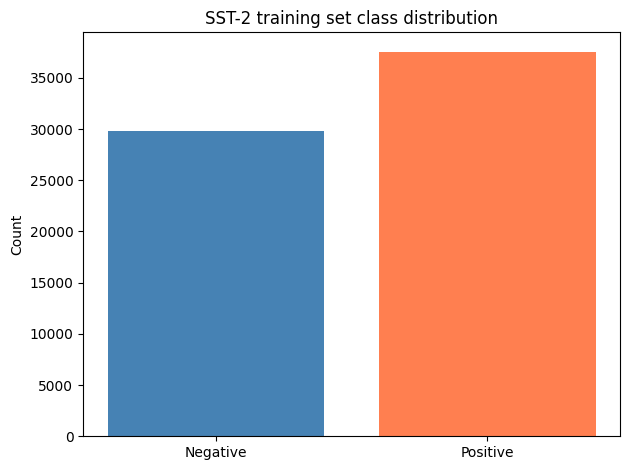

In [13]:
labels = raw_datasets['train']['label']
counts = Counter(labels)
print(f"Negative (0): {counts[0]:,}   Positive (1): {counts[1]:,}")

plt.bar(['Negative', 'Positive'], [counts[0], counts[1]], color=['steelblue', 'coral'])
plt.title('SST-2 training set class distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 3 — Tokenisation
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████


BERT uses WordPiece tokenisation. Every sequence is wrapped with `[CLS]` at the start and `[SEP]` at the end.

In [15]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [16]:
len(tokenizer)   # vocabulary size

30522

In [17]:
tokenizer.model_max_length     # max sequence length for the model/tokenizer

512

In [28]:
vocab = tokenizer.get_vocab()
id_to_token = {idx: tok for tok, idx in vocab.items()}
print(' // '.join(id_to_token[i] for i in range(3000, 5000)))

paris // systems // saint // leader // theatre // whose // market // capital // parents // spanish // canadian // earth // ##ity // cut // degree // writing // bay // christian // awarded // natural // higher // bill // ##as // coast // provided // previous // senior // ft // valley // organization // stopped // onto // countries // parts // conference // queen // security // interest // saying // allowed // master // earlier // phone // matter // smith // winning // try // happened // moving // campaign // los // ##ley // breath // nearly // mid // 1987 // certain // girls // date // italian // african // standing // fell // artist // ##ted // shows // deal // mine // industry // 1986 // ##ng // everyone // republic // provide // collection // library // student // ##ville // primary // owned // older // via // heavy // 1st // makes // ##able // attention // anyone // africa // ##ri // stated // length // ended // fingers // command // staff // skin // foreign // opening // governor /

In [30]:
example = 'This film was absolutely fantastic!'

tokens  = tokenizer.tokenize(example)
encoded = tokenizer(example, return_tensors='pt')

print('Tokens :', tokens)
print('Input IDs:', encoded['input_ids'])
print('Decoded :', tokenizer.decode(encoded['input_ids'][0]))

Tokens : ['this', 'film', 'was', 'absolutely', 'fantastic', '!']
Input IDs: tensor([[  101,  2023,  2143,  2001,  7078, 10392,   999,   102]])
Decoded : [CLS] this film was absolutely fantastic! [SEP]


In [32]:
example = 'Thes films were absolutely fantasttics!!'

tokens  = tokenizer.tokenize(example)
encoded = tokenizer(example, return_tensors='pt')

print('Tokens :', tokens)
print('Input IDs:', encoded['input_ids'])
print('Decoded :', tokenizer.decode(encoded['input_ids'][0]))

Tokens : ['the', '##s', 'films', 'were', 'absolutely', 'fan', '##tas', '##tti', '##cs', '!', '!']
Input IDs: tensor([[  101,  1996,  2015,  3152,  2020,  7078,  5470, 10230,  6916,  6169,
           999,   999,   102]])
Decoded : [CLS] thes films were absolutely fantasttics!! [SEP]


In [35]:
def tokenize_function(batch):
    return tokenizer(
        batch['sentence'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
    )

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')
tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print('Tokenisation done. Columns:', tokenized_datasets['train'].column_names)

Tokenisation done. Columns: ['sentence', 'labels', 'idx', 'input_ids', 'token_type_ids', 'attention_mask']


In [38]:
tokenized_datasets.reset_format()

for i in range(5):
    ex = tokenized_datasets["train"][i]
    print(f"[{ex['labels']}] {ex['sentence']}")
    print("input_ids:", ex["input_ids"])
    print("token_type_ids:", ex["token_type_ids"])
    print("attention_mask:", ex["attention_mask"])
    print()

tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

[0] hide new secretions from the parental units 
input_ids: [101, 5342, 2047, 3595, 8496, 2013, 1996, 18643, 3197, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
token_type_ids: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
## 4 — Regime 1: Feature extraction (frozen BERT)
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

Extract `[CLS]` embeddings without updating BERT, then train logistic regression on top.

In [41]:
from datasets.utils.logging import disable_progress_bar
from transformers import logging as hf_logging
from torch.utils.data import DataLoader

disable_progress_bar()
hf_logging.set_verbosity_error()

bert_encoder = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_encoder.eval()

def extract_cls_embeddings(model, dataset, batch_size=64, max_samples=None):
    subset = dataset.select(range(max_samples)) if max_samples else dataset
    loader = DataLoader(subset, batch_size=batch_size)
    all_emb, all_lbl = [], []

    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            out = model(input_ids=ids, attention_mask=mask)
            cls = out.last_hidden_state[:, 0, :].cpu().numpy()
            all_emb.append(cls)
            all_lbl.append(batch['labels'].numpy())

    return np.concatenate(all_emb), np.concatenate(all_lbl)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [43]:
print('Extracting training embeddings...')
X_train, y_train = extract_cls_embeddings(bert_encoder, tokenized_datasets['train'], max_samples=5000)
print('Extracting validation embeddings...')
X_val, y_val = extract_cls_embeddings(bert_encoder, tokenized_datasets['validation'])


Extracting training embeddings...
Extracting validation embeddings...


In [44]:
print(f'X_train shape: {X_train.shape},  X_val shape: {X_val.shape}')
print(f'y_train shape: {y_train.shape},  y_val shape: {y_val.shape}')

X_train shape: (5000, 768),  X_val shape: (872, 768)
y_train shape: (5000,),  y_val shape: (872,)


In [47]:
X_train[112]

array([ 8.86081383e-02, -4.79602292e-02, -4.41638418e-02, -3.07244301e-01,
       -1.30135328e-01, -8.63199472e-01,  5.17221466e-02,  4.68546718e-01,
        9.05391514e-01, -5.80924973e-02, -4.29336846e-01, -2.51411915e-01,
        8.33726749e-02,  5.72865903e-01,  2.48019546e-02,  3.01821053e-01,
       -1.70848429e-01,  4.37418729e-01, -1.65228527e-02, -5.29043674e-01,
       -3.17854822e-01, -8.10791075e-01,  2.46687397e-01, -2.25375354e-01,
        2.60743290e-01,  4.64385152e-01, -1.80496275e-03, -5.66120371e-02,
       -3.82059723e-01,  8.04539099e-02,  3.44354033e-01,  7.69928396e-02,
       -9.10511672e-01, -1.02406132e+00, -1.09334350e-01, -4.16004956e-02,
        1.05855018e-01,  5.57723641e-01, -6.23814575e-02,  7.26707458e-01,
       -4.17588174e-01,  1.00854293e-01,  7.02305317e-01, -3.68733406e-01,
       -1.77430153e-01, -7.63321877e-01, -2.90133333e+00, -1.04906991e-01,
       -6.18722066e-02, -1.38265297e-01,  6.07983708e-01, -1.77181512e-01,
        4.55899946e-02,  

In [49]:
y_train[112]

1

In [51]:
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

<font color='teal'>


**Comments:**

`bert-base-uncased` produces, for each token in the input sentence, a vector of size 768. `X_train` is the matrix made of the `[CLS]` token representations for all training sentences.
 
The logistic regression sees:

- 5000 input vectors for training
- 872 input vectors for validation
- each input vector has 768 variables


</font>

**RESULTS:**

In [56]:
val_preds  = clf.predict(X_val)
acc_frozen = accuracy_score(y_val, val_preds)
print(f'Validation accuracy (frozen BERT + LR): {acc_frozen:.4f}')

Validation accuracy (frozen BERT + LR): 0.8337


In [58]:
label_name = {0: "negative", 1: "positive"}
val_sentences = raw_datasets["validation"]["sentence"]

for i in range(30):
    true_label = y_val[i]
    pred_label = val_preds[i]
    sentence = val_sentences[i]

    print(f"Sentence : {sentence}")
    print(f"True     : {label_name[int(true_label)]}")
    print(f"Predicted: {label_name[int(pred_label)]}")
    print(f"Correct  : {true_label == pred_label}")
    print("-" * 60)

Sentence : it 's a charming and often affecting journey . 
True     : positive
Predicted: positive
Correct  : True
------------------------------------------------------------
Sentence : unflinchingly bleak and desperate 
True     : negative
Predicted: positive
Correct  : False
------------------------------------------------------------
Sentence : allows us to hope that nolan is poised to embark a major career as a commercial yet inventive filmmaker . 
True     : positive
Predicted: positive
Correct  : True
------------------------------------------------------------
Sentence : the acting , costumes , music , cinematography and sound are all astounding given the production 's austere locales . 
True     : positive
Predicted: positive
Correct  : True
------------------------------------------------------------
Sentence : it 's slow -- very , very slow . 
True     : negative
Predicted: negative
Correct  : True
------------------------------------------------------------
Sentence : altho

In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, val_preds)
print(cm)

[[340  88]
 [ 57 387]]


███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 5 — Regime 2: Full fine-tuning
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

Train BERT + classification head jointly using the HuggingFace `Trainer` API.

In [64]:
metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [66]:
model_ft = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

training_args = TrainingArguments(
    output_dir='./bert_sst2_finetuned',
    num_train_epochs=3,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    seed=SEED,
    report_to='none',
)

TRAIN_SUBSET = 5000  # set to None to use the full training set (5000)

trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=tokenized_datasets['train'].select(range(TRAIN_SUBSET)),
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics,
)

# Remove the NotebookProgressCallback that conflicts with nbconvert execution
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.pop_callback(NotebookProgressCallback)
except Exception:
    pass

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

{'eval_loss': '0.2714', 'eval_accuracy': '0.8968', 'eval_runtime': '4.146', 'eval_samples_per_second': '210.3', 'eval_steps_per_second': '6.753', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.2417', 'eval_accuracy': '0.9071', 'eval_runtime': '4.101', 'eval_samples_per_second': '212.6', 'eval_steps_per_second': '6.827', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.2875', 'eval_accuracy': '0.9106', 'eval_runtime': '4.21', 'eval_samples_per_second': '207.1', 'eval_steps_per_second': '6.65', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '261.5', 'train_samples_per_second': '57.36', 'train_steps_per_second': '1.801', 'train_loss': '0.2533', 'epoch': '3'}


TrainOutput(global_step=471, training_loss=0.253310574088127, metrics={'train_runtime': 261.5266, 'train_samples_per_second': 57.356, 'train_steps_per_second': 1.801, 'train_loss': 0.253310574088127, 'epoch': 3.0})

In [68]:
results_ft = trainer.evaluate()
acc_ft     = results_ft['eval_accuracy']
print(f'Validation accuracy (fine-tuned BERT):  {acc_ft:.4f}')
print(f'Improvement over frozen BERT:           +{acc_ft - acc_frozen:.4f}')

{'eval_loss': '0.2419', 'eval_accuracy': '0.906', 'eval_runtime': '4.089', 'eval_samples_per_second': '213.3', 'eval_steps_per_second': '6.848', 'epoch': '3'}
Validation accuracy (fine-tuned BERT):  0.9060
Improvement over frozen BERT:           +0.0722


In [71]:
pred_output = trainer.predict(tokenized_datasets["validation"])
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = pred_output.label_ids
cmFull = confusion_matrix(y_true, y_pred)
print(cmFull)

[[378  50]
 [ 32 412]]


**Previous result with the Logistic Regression only:**

In [74]:
cm = confusion_matrix(y_val, val_preds)
print(cm)

[[340  88]
 [ 57 387]]


███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 6 — Visualise CLS embeddings with PCA
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

Project 768-dimensional `[CLS]` embeddings to 2D and compare **before** and **after** fine-tuning.

Extracting fine-tuned validation embeddings...


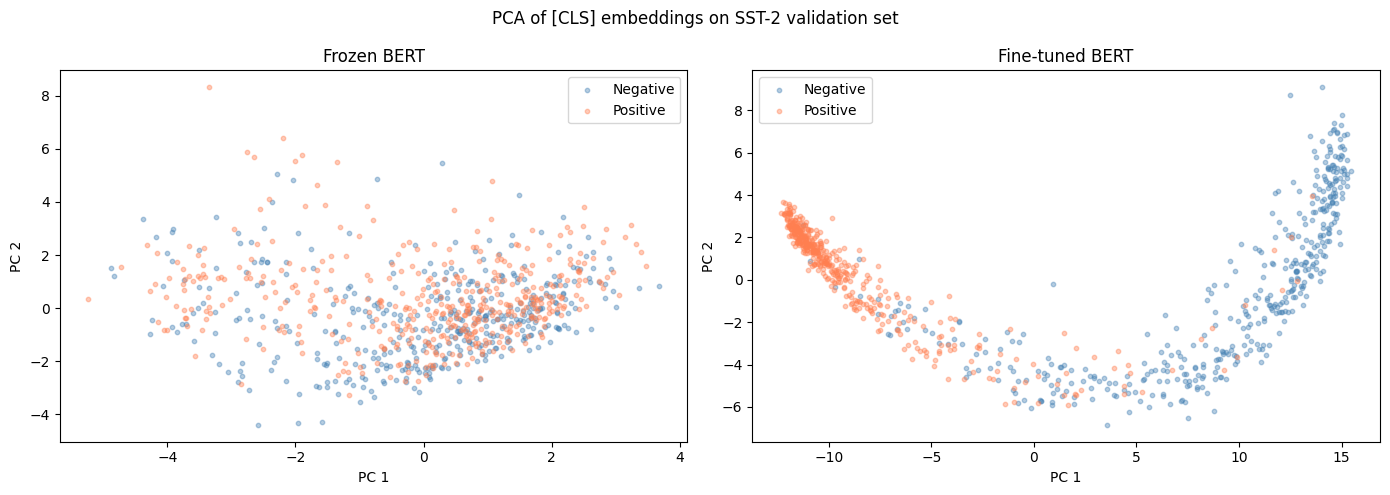

In [77]:
from sklearn.decomposition import PCA

ft_encoder = model_ft.bert.to(device)
ft_encoder.eval()

print('Extracting fine-tuned validation embeddings...')
X_val_ft, y_val_ft = extract_cls_embeddings(ft_encoder, tokenized_datasets['validation'])

Z_frozen = PCA(n_components=2, random_state=SEED).fit_transform(X_val)
Z_ft     = PCA(n_components=2, random_state=SEED).fit_transform(X_val_ft)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, Z, y, title in zip(
    axes,
    [Z_frozen, Z_ft],
    [y_val, y_val_ft],
    ['Frozen BERT', 'Fine-tuned BERT'],
):
    for label, color, name in [(0, 'steelblue', 'Negative'), (1, 'coral', 'Positive')]:
        mask = (y == label)
        ax.scatter(Z[mask, 0], Z[mask, 1], c=color, label=name, alpha=0.4, s=10)
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
plt.suptitle('PCA of [CLS] embeddings on SST-2 validation set')
plt.tight_layout()
plt.show()

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 7 — Error analysis
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

Examine the sentences the fine-tuned model gets wrong.

In [80]:
predictions = trainer.predict(tokenized_datasets['validation'])
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

val_sentences = raw_datasets['validation']['sentence']
errors = [
    {'sentence': val_sentences[i], 'true': int(true_labels[i]), 'pred': int(pred_labels[i])}
    for i in range(len(true_labels))
    if true_labels[i] != pred_labels[i]
]

label_name = {0: 'negative', 1: 'positive'}
print(f'Misclassified: {len(errors)} / {len(true_labels)} ({100*len(errors)/len(true_labels):.1f}%)')
print()
for err in errors:
    t = label_name[err['true']]
    p = label_name[err['pred']]
    print(f'  True: {t:<10}  Pred: {p}')
    print(f'  {repr(err["sentence"])}')
    print()

Misclassified: 82 / 872 (9.4%)

  True: negative    Pred: positive
  'pumpkin takes an admirable look at the hypocrisy of political correctness , but it does so with such an uneven tone that you never know when humor ends and tragedy begins . '

  True: negative    Pred: positive
  'holden caulfield did it better . '

  True: negative    Pred: positive
  'a synthesis of cliches and absurdities that seems positively decadent in its cinematic flash and emptiness . '

  True: negative    Pred: positive
  'it feels like an after-school special gussied up with some fancy special effects , and watching its rote plot points connect is about as exciting as gazing at an egg timer for 93 minutes . '

  True: negative    Pred: positive
  'manages to be both repulsively sadistic and mundane . '

  True: negative    Pred: positive
  "the script kicks in , and mr. hartley 's distended pace and foot-dragging rhythms follow . "

  True: positive    Pred: negative
  "though it 's become almost redundan

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 8 — Inference on custom sentences
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████

Use the fine-tuned model to predict sentiment on new sentences.

In [82]:
from transformers import pipeline

sentiment_pipe = pipeline(
    'sentiment-analysis',
    model=model_ft,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

custom_sentences = [
    'The acting was superb and the story deeply moving.',
    'A dull, predictable waste of two hours.',
    'Not bad, but not particularly memorable either.',
    'One of the best films I have seen this year!',
    'The plot made no sense whatsoever.',
]

results = sentiment_pipe(custom_sentences)
for sentence, result in zip(custom_sentences, results):
    print(f"[{result['label']}  {result['score']:.3f}]  {sentence}")

[LABEL_1  0.992]  The acting was superb and the story deeply moving.
[LABEL_0  0.984]  A dull, predictable waste of two hours.
[LABEL_0  0.951]  Not bad, but not particularly memorable either.
[LABEL_1  0.990]  One of the best films I have seen this year!
[LABEL_0  0.980]  The plot made no sense whatsoever.


In [85]:
custom_sentences = [
    'this movie is great',
    'this movie is greeeeeeeeat',
    'this movie is crazy',
    'this movie is craaaaaaaazzzzzzyyyy',
    'this movie is awesome',
    'this movie is mad',
    'this movie is half great, half shit',
    'this movie is impressive',
    'this movie is amazing',
    'this movie is an abomination',
    'this movie is an abomination',
    'this movie is maddening',
    'this movie is ...',
    'this movie is f... awesome',
    'this movie is f... bad',
    'this movie is f... good',
    'this movie is terrific',
    'this movie is terrible',
    'this movie is annoying',
    'this movie is not great',
    'this movie is not greeeeeeeeat',
    'this movie is not crazy',
    'this movie is not craaaaaaaazzzzzzyyyy',
    'this movie is not awesome',
    'this movie is not mad',
    'this movie is not half great, half shit',
    'this movie is not impressive',
    'this movie is not amazing',
    'this movie is not an abomination',
    'this movie is not an abomination',
    'this movie is not maddening',
    'this movie is not ...',
    'this movie is not f... awsome',
    'this movie is not f... bad',
    'this movie is not f... good',
    'this movie is not terrific',
    'this movie is not terrible',
    'this movie is not annoying',
    '...',
    '....',
    'f...',
    'Trump',
    'Obama',
    'This movie made me cry',
    'This movy made me cry',
    'This movie made cry',
    'movie made me cryyyy',
    'This movie made me not cry',
    'This movie made me laugh',
    'This movie scared me',
    'scaring'
]

results = sentiment_pipe(custom_sentences)
for sentence, result in zip(custom_sentences, results):
    print(f"[{result['label']}  {result['score']:.3f}]  {sentence}")

[LABEL_1  0.991]  this movie is great
[LABEL_0  0.817]  this movie is greeeeeeeeat
[LABEL_0  0.977]  this movie is crazy
[LABEL_0  0.697]  this movie is craaaaaaaazzzzzzyyyy
[LABEL_1  0.990]  this movie is awesome
[LABEL_0  0.982]  this movie is mad
[LABEL_1  0.810]  this movie is half great, half shit
[LABEL_1  0.990]  this movie is impressive
[LABEL_1  0.992]  this movie is amazing
[LABEL_0  0.976]  this movie is an abomination
[LABEL_0  0.976]  this movie is an abomination
[LABEL_0  0.703]  this movie is maddening
[LABEL_0  0.750]  this movie is ...
[LABEL_1  0.987]  this movie is f... awesome
[LABEL_0  0.982]  this movie is f... bad
[LABEL_1  0.979]  this movie is f... good
[LABEL_1  0.991]  this movie is terrific
[LABEL_0  0.984]  this movie is terrible
[LABEL_0  0.984]  this movie is annoying
[LABEL_0  0.979]  this movie is not great
[LABEL_0  0.932]  this movie is not greeeeeeeeat
[LABEL_0  0.663]  this movie is not crazy
[LABEL_0  0.947]  this movie is not craaaaaaaazzzzzzyyyy


███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 9 — Optional: attention visualisation
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████


BERT returns attention weights for each of its 144 heads (12 layers × 12 heads). We inspect which tokens the model focuses on.

In [87]:
from transformers import BertModel

sentence = 'The film was surprisingly good despite a weak script.'
inputs   = tokenizer(sentence, return_tensors='pt').to(device)

# attn_implementation must be set at model creation, not forward time.
# We create a fresh BertModel with 'eager' attention and copy fine-tuned weights.
bert_eager = BertModel.from_pretrained(
    MODEL_NAME, attn_implementation='eager'
).to(device)
bert_eager.load_state_dict(model_ft.bert.state_dict())
bert_eager.eval()

with torch.no_grad():
    outputs = bert_eager(**inputs, output_attentions=True)

tokens   = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
n_layers = len(outputs.attentions)
print(f'Sequence length: {len(tokens)},  Layers: {n_layers},  '
      f'Heads per layer: {outputs.attentions[0].shape[1]}')
print('Tokens:', tokens)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Sequence length: 12,  Layers: 12,  Heads per layer: 12
Tokens: ['[CLS]', 'the', 'film', 'was', 'surprisingly', 'good', 'despite', 'a', 'weak', 'script', '.', '[SEP]']


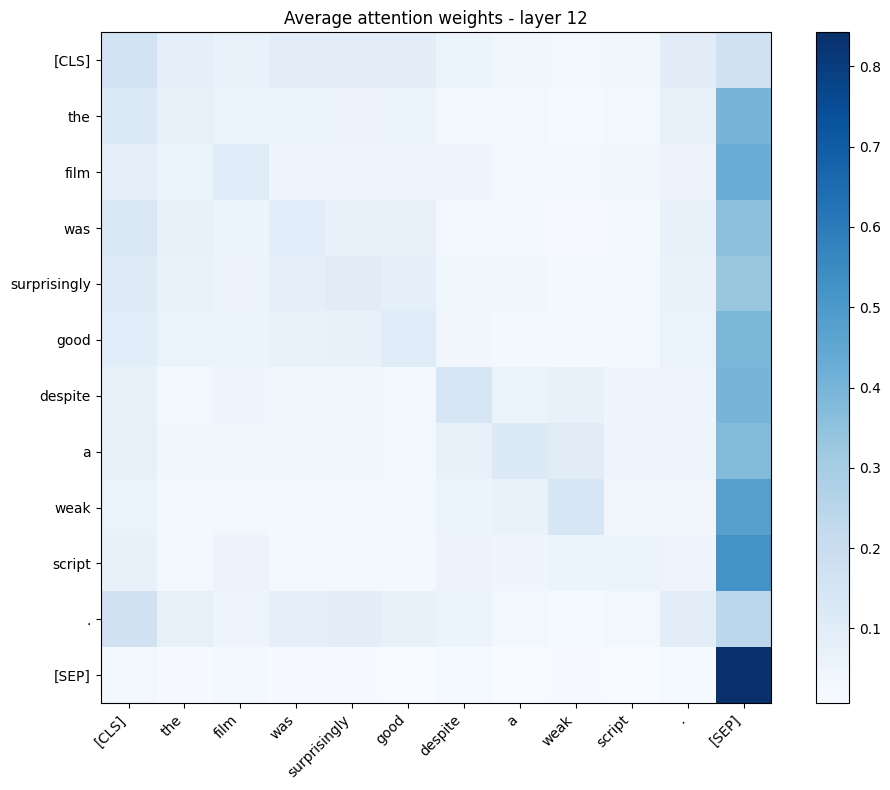

In [88]:
layer_idx = 11  # last layer
attn = outputs.attentions[layer_idx][0].mean(dim=0).cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(attn, cmap='Blues')
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right')
ax.set_yticklabels(tokens)
plt.colorbar(im, ax=ax)
ax.set_title(f'Average attention weights - layer {layer_idx + 1}')
plt.tight_layout()
plt.show()

███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████
# 10 — BERT vizualization
███████████████████████████████████████████████████████████████████████████████████████████
███████████████████████████████████████████████████████████████████████████████████████████


Final sentiment classifier model_ft:

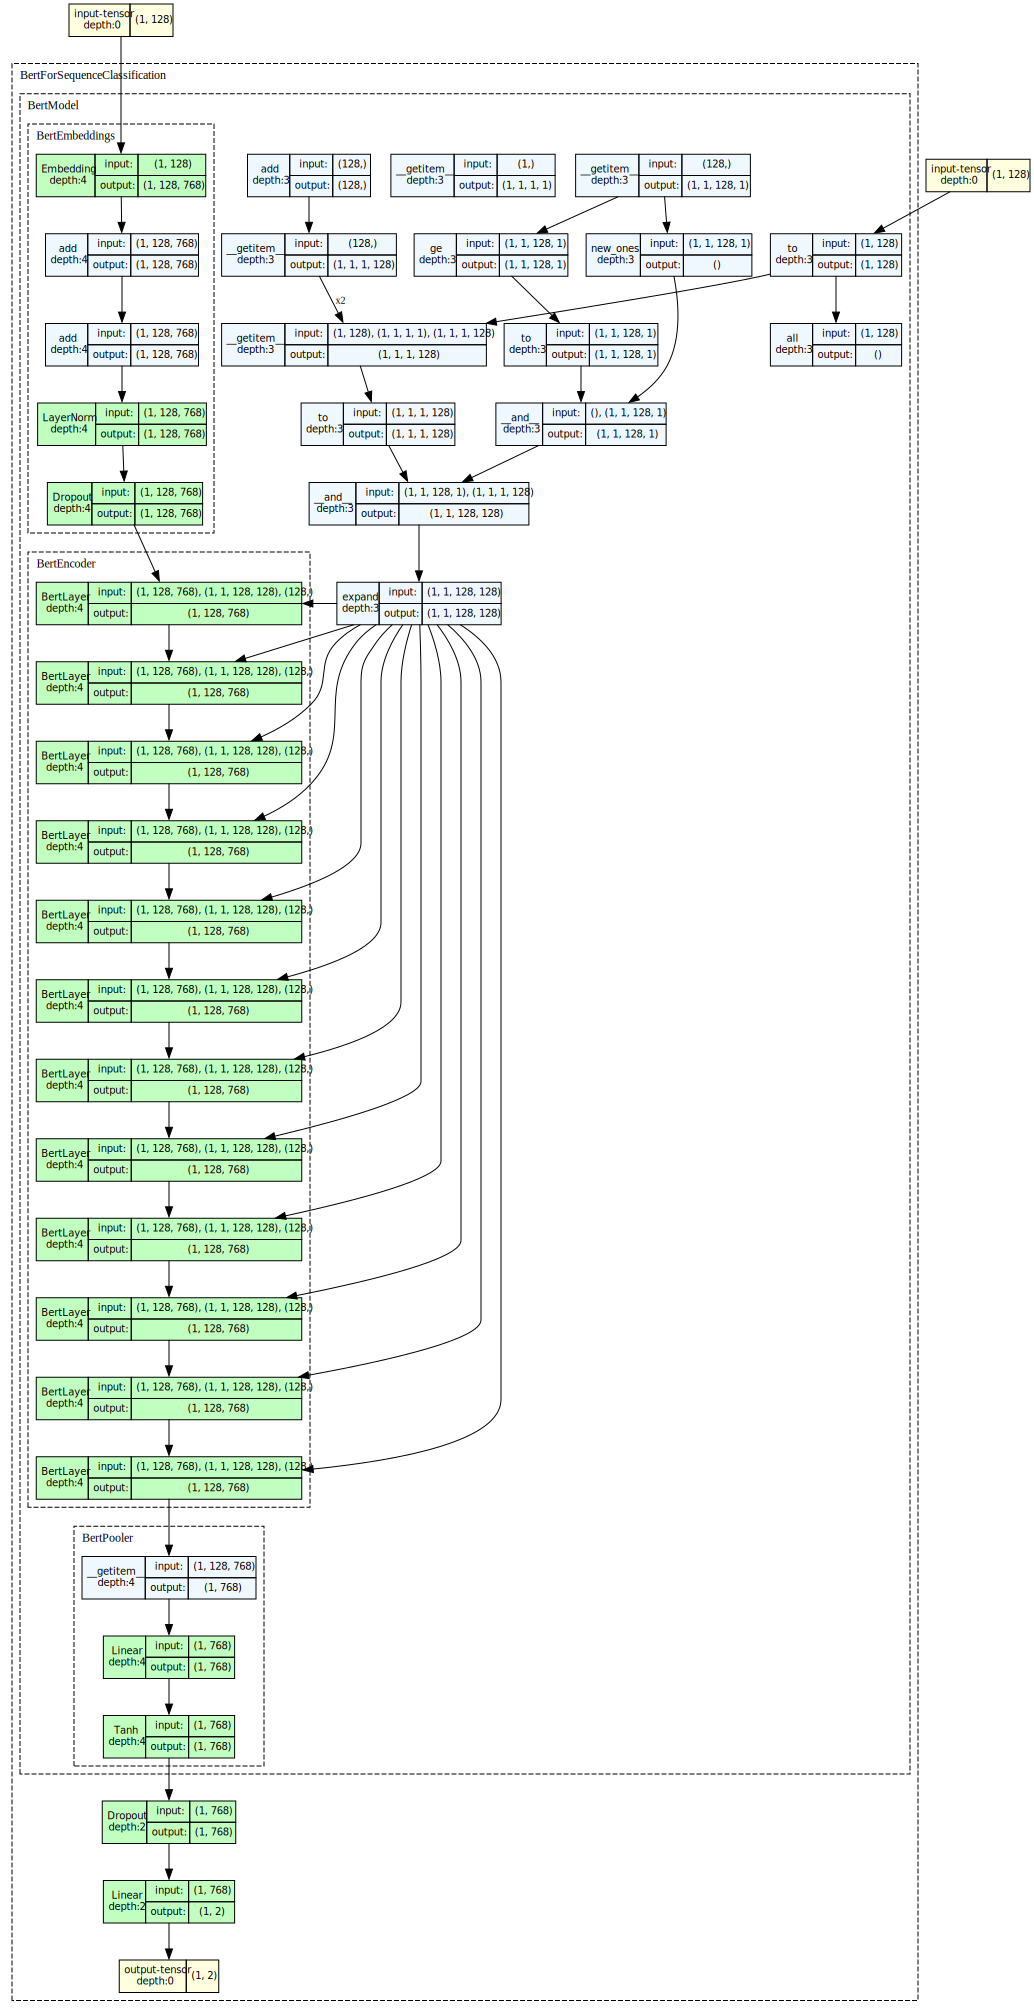

In [108]:
from torchview import draw_graph
import torch.nn as nn

# Wrapper: return only logits, which torchview handles well
class BertSentimentWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, input_ids, attention_mask):
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return out.logits

m = BertSentimentWrapper(model_ft).to(device)
m.eval()

# Dummy tokenized input, same idea as dummy_idx for nanoGPT
dummy_batch = tokenizer(
    "The film was surprisingly good despite a weak script.",
    return_tensors="pt",
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN,
)

dummy_input_ids = dummy_batch["input_ids"].to(device)
dummy_attention = dummy_batch["attention_mask"].to(device)

model_graph = draw_graph(
    m,
    input_data=[dummy_input_ids, dummy_attention],   # input_ids, attention_mask
    graph_name="BERT_sentiment",
    depth=4,                                         # try 5 if you want more detail
    expand_nested=True,
    roll=True
)

model_graph.visual_graph

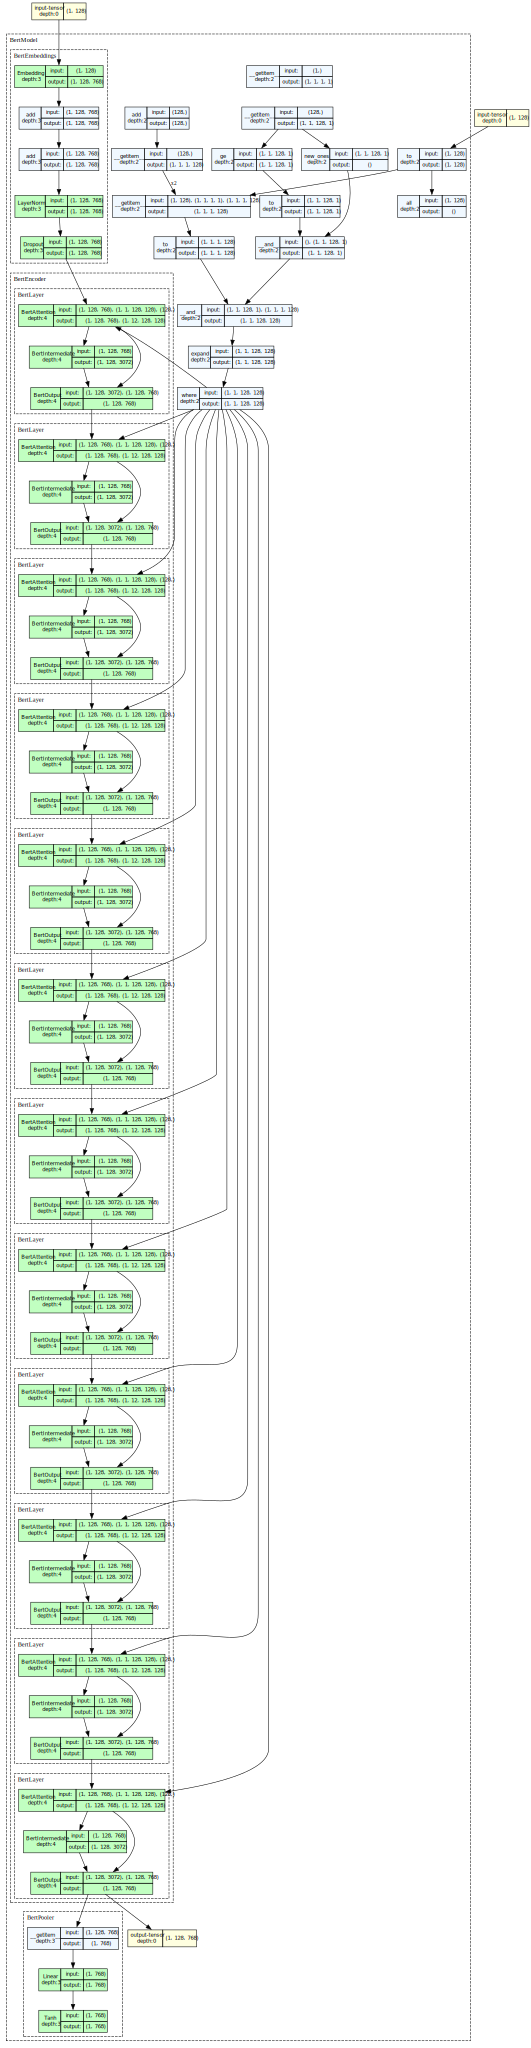

In [110]:
from torchview import draw_graph
import torch.nn as nn

class BertEncoderWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, input_ids, attention_mask):
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state   # tensor output

m = BertEncoderWrapper(bert_eager).to(device)
m.eval()

dummy_batch = tokenizer(
    "The film was surprisingly good despite a weak script.",
    return_tensors="pt",
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN,
)

dummy_input_ids = dummy_batch["input_ids"].to(device)
dummy_attention = dummy_batch["attention_mask"].to(device)

model_graph = draw_graph(
    m,
    input_data=[dummy_input_ids, dummy_attention],
    graph_name="BERT_encoder",
    depth=4,
    expand_nested=True,
    roll=True
)

model_graph.visual_graph

In [128]:
n_total = sum(p.numel() for p in model_ft.parameters())
n_train = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)

print(f"Total parameters:     {n_total:,} ({n_total/1e6:.2f} M)")
print(f"Trainable parameters: {n_train:,} ({n_train/1e6:.2f} M)")

Total parameters:     109,483,778 (109.48 M)
Trainable parameters: 109,483,778 (109.48 M)



In the same spirit as section 7 of the nano-GPT notebook, we decompose the total number of trainable parameters into embeddings, Transformer blocks, normalization layers, and the final prediction head. For BERT sentiment classification, the prediction is made from the final representation of the special token $[\mathrm{CLS}]$, passed through a linear classifier and a softmax. In Hugging Face’s BERT, the sequence-classification head is a linear layer on top of the pooled output, and the standard `bert-base-uncased` configuration uses hidden size $768$, $12$ encoder layers, $12$ attention heads, intermediate size $3072$, vocabulary size $30522$, and maximum positional size $512$. ([Hugging Face][1])

# Total number of trainable parameters

For a BERT sentiment classifier based on `bert-base-uncased` with $2$ output classes, the total number of trainable parameters is

$$
\boxed{109{,}483{,}778}.
$$

## 1. Embedding layer

BERT first builds an input representation by summing three embeddings:

* token embeddings,
* positional embeddings,
* token-type embeddings,

and then applies a LayerNorm. Using the standard BERT-base dimensions, this gives: 

$$
\underbrace{30522 \times 768}*{\text{word embeddings}}
;+;
\underbrace{512 \times 768}*{\text{position embeddings}}
;+;
\underbrace{2 \times 768}*{\text{token-type embeddings}}
;+;
\underbrace{768 + 768}*{\text{LayerNorm }(\gamma,\beta)}.
$$

So the embedding block contributes

$$
23{,}440{,}896 + 393{,}216 + 1{,}536 + 1{,}536 = 23{,}837{,}184.
$$

Comment: **Token-type embeddings** (also called **segment embeddings**) indicate whether a token belongs to the first sentence or the second sentence in the input. Typically, tokens from the first sentence get type $0$, and tokens from the second sentence get type $1$. For a single-sentence input, all token-type ids are usually $0$.

## 2. One Transformer encoder layer

Each BERT layer has two main parts:

1. multi-head self-attention,
2. a feed-forward network.

A useful difference with nano-GPT is that, in BERT, the $12$ heads are implemented jointly through three large matrices
$$
W_Q,;W_K,;W_V \in \mathbb{R}^{768 \times 768},
$$
then reshaped into $12$ heads of size $64$. So we do **not** count one small head and multiply afterward; instead we count the full projections directly. The BERT-base configuration has hidden size $768$, $12$ heads, and intermediate size $3072$. 

### (a) Self-attention part

There are three projections for queries, keys, and values:

$$
3 \times (768 \times 768 + 768).
$$

This gives

$$
3 \times 590{,}592 = 1{,}771{,}776.
$$

Then the attention output projection contributes

$$
768 \times 768 + 768 = 590{,}592.
$$

Finally, the LayerNorm after attention contributes

$$
768 + 768 = 1{,}536.
$$

So the attention sub-block contributes

$$
1{,}771{,}776 + 590{,}592 + 1{,}536
= 2{,}363{,}904.
$$

### (b) Feed-forward part

The feed-forward network expands from $768$ to $3072$, applies a nonlinearity, then projects back to $768$:

$$
768 \to 3072 \to 768.
$$

The first linear layer contributes

$$
768 \times 3072 + 3072 = 2{,}362{,}368.
$$

The second linear layer contributes

$$
3072 \times 768 + 768 = 2{,}360{,}064.
$$

The LayerNorm after the feed-forward block contributes again

$$
768 + 768 = 1{,}536.
$$

So the feed-forward sub-block contributes

$$
2{,}362{,}368 + 2{,}360{,}064 + 1{,}536
= 4{,}723{,}968.
$$

### (c) Total for one encoder layer

Adding attention and feed-forward:

$$
2{,}363{,}904 + 4{,}723{,}968
= 7{,}087{,}872.
$$

## 3. All $12$ encoder layers

Since BERT-base has $12$ encoder layers, the full encoder stack contributes

$$
12 \times 7{,}087{,}872
= 85{,}054{,}464.
$$

## 4. Pooler

BERT also has a pooler, which is a dense layer applied to the final $[\mathrm{CLS}]$ representation before classification. Its size is

$$
768 \times 768 + 768 = 590{,}592.
$$

The sequence-classification version of BERT is documented as using a linear layer on top of the pooled output. ([Hugging Face][1])

## 5. Final classification head

For binary sentiment analysis, the classifier maps the pooled $[\mathrm{CLS}]$ vector in $\mathbb{R}^{768}$ to $2$ logits:

$$
\hat y = \mathrm{softmax}(W h_{[\mathrm{CLS}]} + b),
\qquad
W \in \mathbb{R}^{2 \times 768},\quad b \in \mathbb{R}^2.
$$

So the classifier contributes

$$
768 \times 2 + 2 = 1{,}538.
$$

## 6. Final total

Now we add everything:

$$
\underbrace{23{,}837{,}184}*{\text{embeddings}}
+
\underbrace{85{,}054{,}464}*{12\ \text{encoder layers}}
+
\underbrace{590{,}592}*{\text{pooler}}
+
\underbrace{1{,}538}*{\text{classifier}}
= 109{,}483{,}778.
$$

Therefore, the total number of trainable parameters is

$$
\boxed{109{,}483{,}778}.
$$

## 7. Important remark

As in nano-GPT, trainable parameters come from:

* embedding tables,
* linear layers,
* LayerNorm scale and bias.

They do **not** come from:

* GELU,
* dropout,
* softmax,
* the attention mask,
* the split into attention heads.

So the main reason BERT has far more parameters than your nano-GPT toy model is that every hidden vector has size $768$ instead of $64$, each feed-forward block expands to $3072$, and there are $12$ encoder layers instead of only a few small blocks. 
